# Homework1

<h1 style="color:green;">
Step 0 — Setup and Sector Filter
</h1>


In [2]:
# 1. Alice Signorelli ,StudentID:1000035114
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Global chart style.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False


In [3]:
# 2.Loading the dataset into a pandas DataFrame.
df_raw = pd.read_csv("symbol_info_3-25.csv")
print("Dataset shape:", df_raw.shape)
df_raw.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [5]:
# 3. Inspect columns and missing values

summary = pd.DataFrame({"column": df_raw.columns,"dtype": df_raw.dtypes.astype(str).values,"missing_values": 
df_raw.isna().sum().values,"missing_pct": (df_raw.isna().mean().values * 100).round(2)})

summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


In [ ]:
 # I create a clean working dataset by removing ETFs and funds, keeping only active Consumer Defensive companies, and
# converting market capitalization into billions to make the analysis easier to read.

df = df_raw.copy()
df = df[(df["is_etf"] == 0) &(df["is_fund"] == 0) &
(df["is_actively_trading"] == 1) &(df["market_cap"] > 0)].copy()

df["market_cap_b"] = df["market_cap"] / 1e9
df = df[df["sector"] == "Consumer Defensive"].copy()
print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (54, 39)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b
13,WMT,Walmart Inc.,Consumer Defensive,Discount Stores,689288773632,749043712000,85.980003,85.574997,105.300003,58.560001,94.990997,82.890350,0.537,35.676350,31.610294,1.012194,7.580005,680984969216,19435999232,0.02854,7926499840,63.580002,0.07148,0.21414,0.041,-0.023,0.94,1.09,0.3444,19481998,2.08,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:19,689.288774
21,COST,Costco Wholesale Corporation,Consumer Defensive,Discount Stores,403423232000,398304542720,909.260010,895.400024,1078.229980,697.270020,984.550171,915.677368,0.805,52.346573,46.202236,1.527621,15.774536,264085995520,7621000192,0.02886,5603500032,31.431000,0.08735,0.32894,0.090,0.026,4.64,0.52,0.2709,2129266,3.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:17,403.423232
23,PG,Procter & Gamble Company (The),Consumer Defensive,Household & Personal Products,392879996928,416383336448,166.690002,167.550003,180.429993,153.520004,167.883408,169.100296,0.400,26.542994,22.464960,4.657956,7.758436,84346003456,15192000512,0.18353,11446250496,67.428001,0.10884,0.31058,0.021,0.341,4.03,2.42,0.6306,7476581,2.61,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:21,392.879997
27,KO,Coca-Cola Company (The),Consumer Defensive,Beverages - Non-Alcoholic,300001361920,328951693312,68.669998,69.709999,73.529999,57.930000,66.826599,66.439247,0.575,27.914633,23.121212,6.374734,11.884735,47061000192,10631000064,0.22590,14962124800,176.919006,0.09017,0.39549,0.064,0.115,2.04,2.97,0.7886,17541486,2.18,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:26,300.001362
35,PM,Philip Morris International Inc,Consumer Defensive,Tobacco,237069221888,279545774080,151.479996,152.470001,159.509995,87.820000,141.725403,124.625549,0.561,25.204657,21.038889,6.258758,-20.044991,37878001664,7033999872,0.18631,8184500224,0.000000,0.12998,0.00000,0.073,0.000,5.40,3.56,0.8820,5915991,2.55,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:29,237.069222


In [8]:
# 5. Helper functions
def billions_formatter(x, pos):
    # Format large values in billions.
    return f"{x:,.0f}B"


def pct_formatter(x, pos):
    # Format percentages.
    return f"{x:.0f}%"


# Remove unnecessary chart borders.
def clean_spines(ax):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


In [9]:
 # I create a clean version of the dataset starting from the raw data,keeping only active companies currently trading,
# removing ETFs and funds,and convert market capitalization into billions to improve readability in the analysis and charts.
df = df_raw.copy()
df = df[(df["is_etf"] == 0) &(df["is_fund"] == 0) & (df["is_actively_trading"] == 1) &
(df["market_cap"] > 0)].copy()

df["market_cap_b"] = df["market_cap"] / 1e9
df = df[df["sector"] == "Consumer Defensive"].copy()

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (54, 39)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b
13,WMT,Walmart Inc.,Consumer Defensive,Discount Stores,689288773632,749043712000,85.980003,85.574997,105.300003,58.560001,94.990997,82.890350,0.537,35.676350,31.610294,1.012194,7.580005,680984969216,19435999232,0.02854,7926499840,63.580002,0.07148,0.21414,0.041,-0.023,0.94,1.09,0.3444,19481998,2.08,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:19,689.288774
21,COST,Costco Wholesale Corporation,Consumer Defensive,Discount Stores,403423232000,398304542720,909.260010,895.400024,1078.229980,697.270020,984.550171,915.677368,0.805,52.346573,46.202236,1.527621,15.774536,264085995520,7621000192,0.02886,5603500032,31.431000,0.08735,0.32894,0.090,0.026,4.64,0.52,0.2709,2129266,3.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:17,403.423232
23,PG,Procter & Gamble Company (The),Consumer Defensive,Household & Personal Products,392879996928,416383336448,166.690002,167.550003,180.429993,153.520004,167.883408,169.100296,0.400,26.542994,22.464960,4.657956,7.758436,84346003456,15192000512,0.18353,11446250496,67.428001,0.10884,0.31058,0.021,0.341,4.03,2.42,0.6306,7476581,2.61,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:21,392.879997
27,KO,Coca-Cola Company (The),Consumer Defensive,Beverages - Non-Alcoholic,300001361920,328951693312,68.669998,69.709999,73.529999,57.930000,66.826599,66.439247,0.575,27.914633,23.121212,6.374734,11.884735,47061000192,10631000064,0.22590,14962124800,176.919006,0.09017,0.39549,0.064,0.115,2.04,2.97,0.7886,17541486,2.18,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:26,300.001362
35,PM,Philip Morris International Inc,Consumer Defensive,Tobacco,237069221888,279545774080,151.479996,152.470001,159.509995,87.820000,141.725403,124.625549,0.561,25.204657,21.038889,6.258758,-20.044991,37878001664,7033999872,0.18631,8184500224,0.000000,0.12998,0.00000,0.073,0.000,5.40,3.56,0.8820,5915991,2.55,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:29,237.069222


<h1 style="color:green;">
Step 1 — Market Capitalization Distribution
</h1>

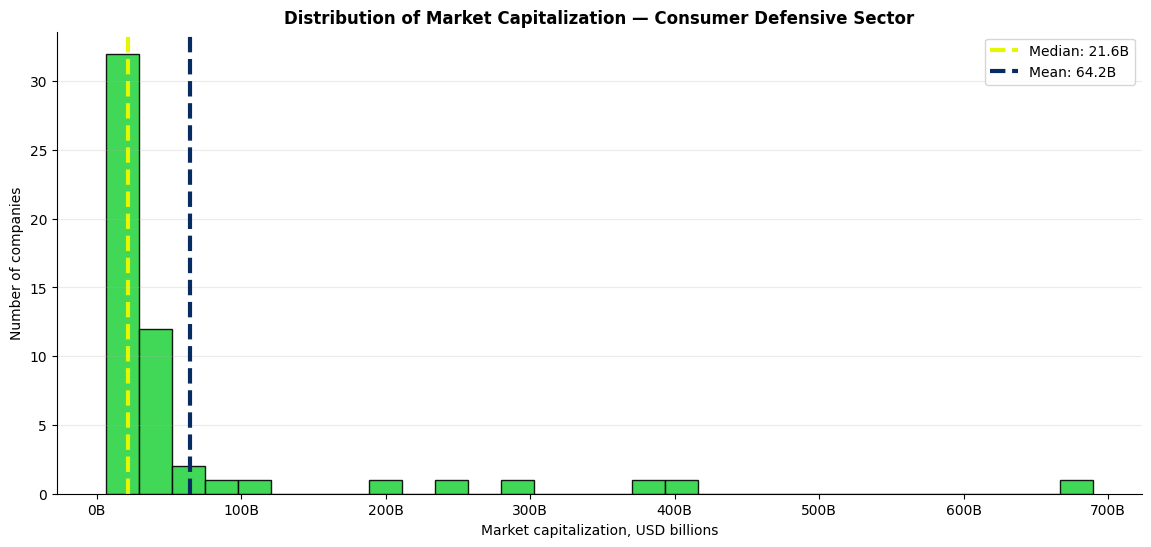

In [10]:
# I used a histogram to visualize the distribution of market capitalization across companies in the Consumer Defensive sector.
# I also added the mean and median lines to see whether the distribution is influenced by a few very large companies.

market_cap = df["market_cap_b"].dropna()
# summary statistics.
median_value = market_cap.median()
mean_value = market_cap.mean()
fig, ax = plt.subplots(figsize=(14, 6))
# histogram.
ax.hist(market_cap,bins=30,color="#2CD445",
edgecolor="black",alpha=0.9)

# Add median line.
ax.axvline(median_value,color="#E5F601",linestyle="--",
linewidth=3,label=f"Median: {median_value:,.1f}B")

# Add mean line.
ax.axvline(mean_value,color="#062C61",
linestyle="--",linewidth=3,label=f"Mean: {mean_value:,.1f}B")

# Titles and labels.
ax.set_title("Distribution of Market Capitalization — Consumer Defensive Sector")

ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")

# Format axis labels.
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Add subtle grid.
ax.grid(axis="y", alpha=0.25)

# Clean chart borders.
clean_spines(ax)

# Add legend.
ax.legend()

plt.show()

<h1 style="color:green;">
Step 2 — Outlier Detection
</h1>

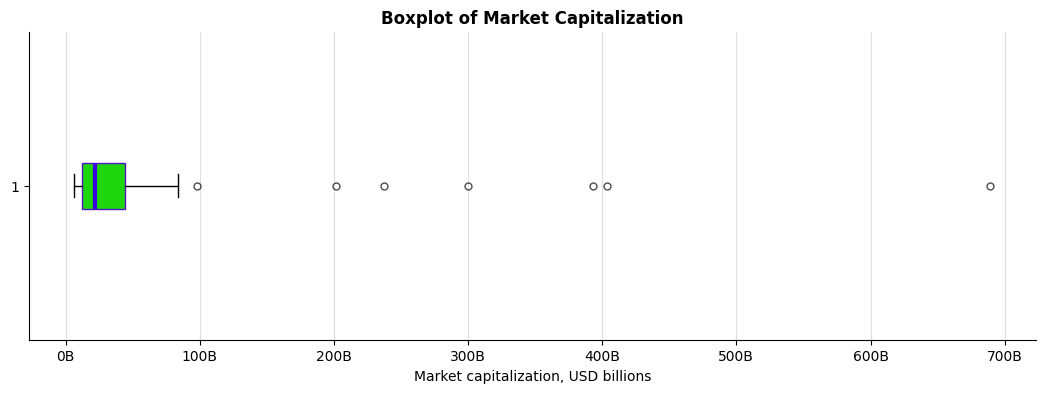

In [ ]:
# A boxplot helps identify the presence of outliers in the market capitalization distribution.
# Extremely large companies may distort the analysis, so we inspect the distribution before continuing.

fig, ax = plt.subplots(figsize=(13, 4))

#horizontal boxplot.
ax.boxplot(df["market_cap_b"].dropna(),vert=False,
patch_artist=True,boxprops={"facecolor": "#1ED60E","edgecolor": "#4E18C4"},
medianprops={"color": "#3902DF","linewidth": 3},
    whiskerprops={"color": "#000000"},
    capprops={"color": "#000000"},
    flierprops={"marker": "o","markersize": 5,"alpha": 0.7})

ax.set_title("Boxplot of Market Capitalization")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

ax.grid(axis="x", alpha=0.4)
clean_spines(ax)
plt.show()

In [17]:
# Remove extreme outliers using the IQR method
# Calculate quartiles.
Q1 = df["market_cap_b"].quantile(0.25)
Q3 = df["market_cap_b"].quantile(0.75)

# Compute IQR.
IQR = Q3 - Q1

# Define lower and upper bounds.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset.
df_clean = df[
    (df["market_cap_b"] >= lower_bound) &
    (df["market_cap_b"] <= upper_bound)
].copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (54, 39)
Cleaned dataset shape: (47, 39)


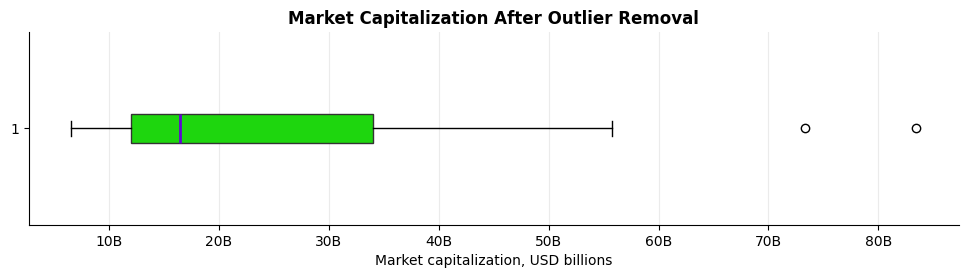

In [18]:
# Boxplot after outlier removal


fig, ax = plt.subplots(figsize=(12, 2.5))

ax.boxplot(
    df_clean["market_cap_b"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops={
        "facecolor": "#1ED60E",
        "edgecolor": "#333333"},
    medianprops={
        "color": "#6206D3",
        "linewidth": 2})

ax.set_title("Market Capitalization After Outlier Removal")
ax.set_xlabel("Market capitalization, USD billions")

ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

plt.show()

<h1 style="color:green;">
Step 3 — Industry Comparison: Four Metrics
</h1>

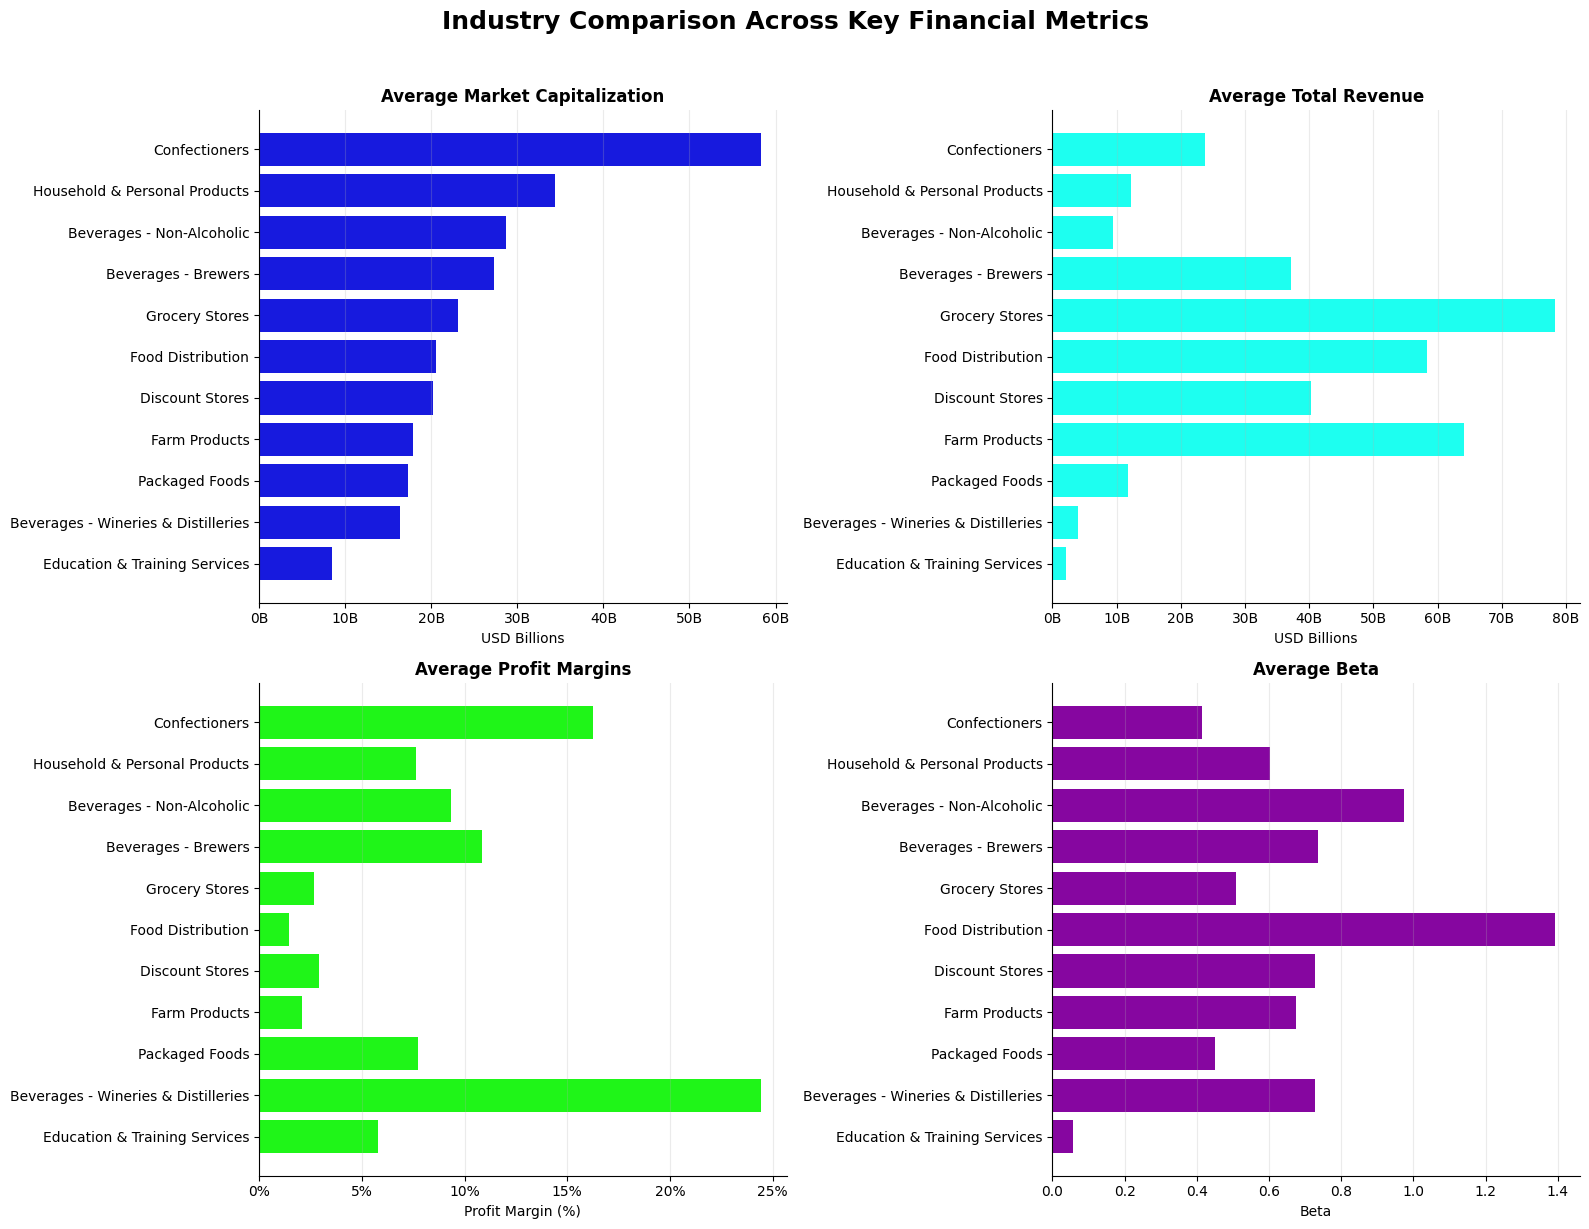

In [19]:
# Step 3 — Industry Comparison: Four Metrics

# This analysis compares industries within the Consumer Defensive sector.
# We compute the average value for four important metrics: market capitalization, total revenue, profit margins, beta

# Using industry averages helps identify:larger industries, more profitable industries,higher-risk industries

# industry summary table.
industry_summary = (
    df_clean
    .groupby("industry")
    .agg(
        avg_market_cap_b=("market_cap_b", "mean"),
        avg_revenue_b=("total_revenue", lambda x: x.mean() / 1e9),
        avg_profit_margin=("profit_margins", lambda x: x.mean() * 100),
        avg_beta=("beta", "mean")
    )
    .dropna()
)

# Sorting industries by average market capitalization.
industry_summary = industry_summary.sort_values(
    "avg_market_cap_b",
    ascending=True
)


# Creating figure with 4 subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12)
)

# Flatten axes array for easier indexing.
axes = axes.flatten()


# Plot 1 — Market Capitalization


axes[0].barh(
    industry_summary.index,
    industry_summary["avg_market_cap_b"],
    color="#171ADE"
)

axes[0].set_title("Average Market Capitalization")
axes[0].set_xlabel("USD Billions")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(billions_formatter)
)

axes[0].grid(axis="x", alpha=0.25)

clean_spines(axes[0])


# Plot 2 — Total Revenue


axes[1].barh(
    industry_summary.index,
    industry_summary["avg_revenue_b"],
    color="#1DFFF0"
)

axes[1].set_title("Average Total Revenue")
axes[1].set_xlabel("USD Billions")

axes[1].xaxis.set_major_formatter(
    FuncFormatter(billions_formatter)
)

axes[1].grid(axis="x", alpha=0.25)

clean_spines(axes[1])


# Plot 3 — Profit Margins


axes[2].barh(
    industry_summary.index,
    industry_summary["avg_profit_margin"],
    color="#1FF518"
)

axes[2].set_title("Average Profit Margins")
axes[2].set_xlabel("Profit Margin (%)")

axes[2].xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

axes[2].grid(axis="x", alpha=0.25)

clean_spines(axes[2])


# Plot 4 — Beta


axes[3].barh(
    industry_summary.index,
    industry_summary["avg_beta"],
    color="#8606A0"
)

axes[3].set_title("Average Beta")
axes[3].set_xlabel("Beta")

axes[3].grid(axis="x", alpha=0.25)

clean_spines(axes[3])

# Global title


fig.suptitle(
    "Industry Comparison Across Key Financial Metrics",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

<h1 style="color:green;">
Step 4 — Industry Dispersion
</h1>

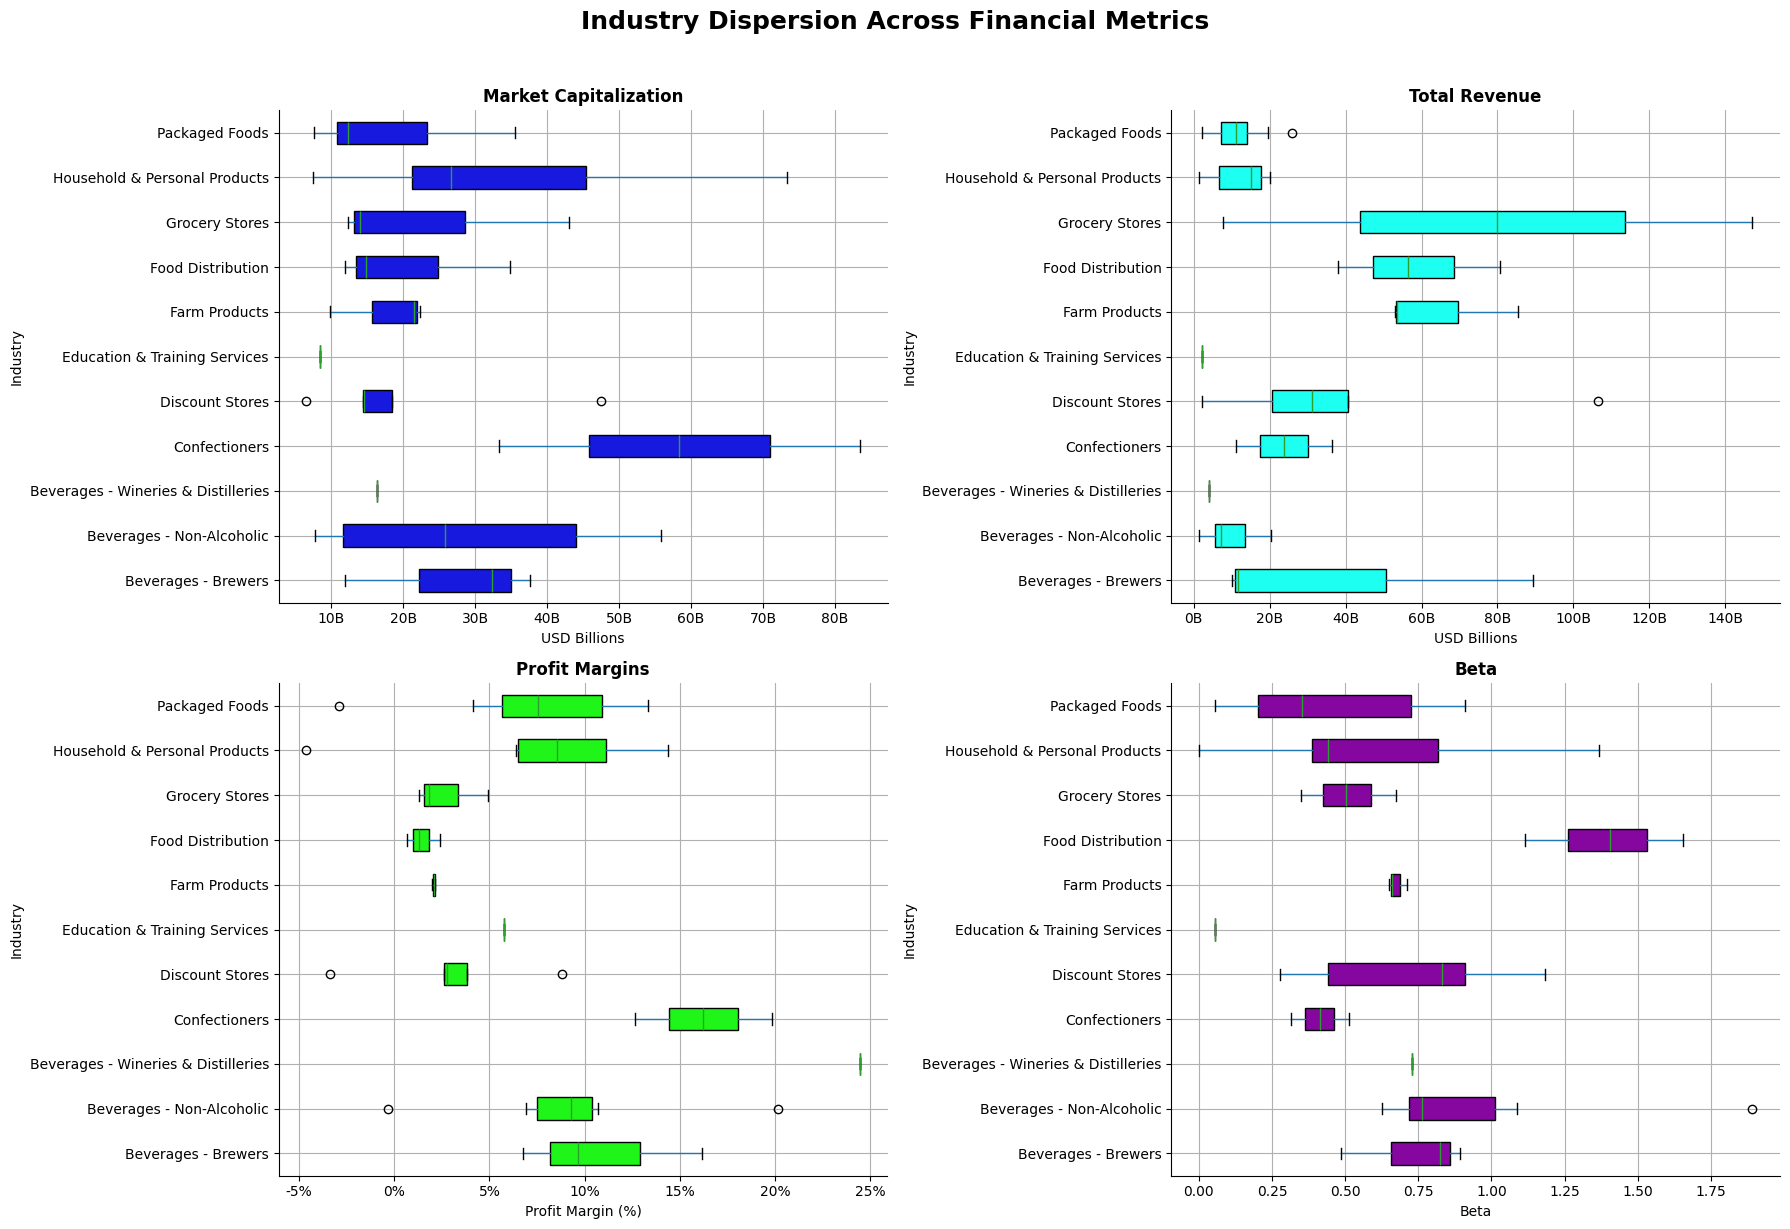

In [20]:
# Boxplots allow us to study the full distribution of valueswithin each industry, not only the average.
# This helps identify:variability,outliers,consistency across companies,differences in industry structure

# Remove rows with missing values in required columns.
box_df = df_clean.dropna(
    subset=[
        "industry",
        "market_cap_b",
        "total_revenue",
        "profit_margins",
        "beta"
    ]
).copy()

box_df["revenue_b"] = box_df["total_revenue"] / 1e9 # Converting revenue to billions.


box_df["profit_margin_pct"] = box_df["profit_margins"] * 100  # Converting profit margins into percentages.


# Creating figure with 4 boxplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 12)
)

axes = axes.flatten()

# Boxplot 1 — Market Capitalization
box_df.boxplot(
    column="market_cap_b",
    by="industry",
    ax=axes[0],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#171ADE")
)

axes[0].set_title("Market Capitalization")
axes[0].set_xlabel("USD Billions")
axes[0].set_ylabel("Industry")

axes[0].xaxis.set_major_formatter(
    FuncFormatter(billions_formatter)
)

clean_spines(axes[0])

# Boxplot 2 — Revenue
box_df.boxplot(
    column="revenue_b",
    by="industry",
    ax=axes[1],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#1DFFF0")
)

axes[1].set_title("Total Revenue")
axes[1].set_xlabel("USD Billions")
axes[1].set_ylabel("Industry")

axes[1].xaxis.set_major_formatter(
    FuncFormatter(billions_formatter)
)

clean_spines(axes[1])

# Boxplot 3 — Profit Margins
box_df.boxplot(
    column="profit_margin_pct",
    by="industry",
    ax=axes[2],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#1FF518")
)

axes[2].set_title("Profit Margins")
axes[2].set_xlabel("Profit Margin (%)")
axes[2].set_ylabel("Industry")

axes[2].xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

clean_spines(axes[2])

# Boxplot 4 — Beta

box_df.boxplot(
    column="beta",
    by="industry",
    ax=axes[3],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#8606A0")
)

axes[3].set_title("Beta")
axes[3].set_xlabel("Beta")
axes[3].set_ylabel("Industry")

clean_spines(axes[3])

plt.suptitle("") # This removes the automatic pandas subtitle.

# Global title.
fig.suptitle(
    "Industry Dispersion Across Financial Metrics",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

<h1 style="color:green;">
Step 5 — Focus Industry Selection
</h1>

In [ ]:
focus_industries = [
    "Discount Stores",
    "Beverages - Non-Alcoholic",
    "Household & Personal Products",
    "Tobacco"
]

# Filtering dataset.
focus_df = df_clean[
    df_clean["industry"].isin(focus_industries)
].copy()

print("Filtered dataset shape:", focus_df.shape)

# industries retained.
focus_df["industry"].value_counts()

Filtered dataset shape: (18, 39)


industry
Household & Personal Products    7
Beverages - Non-Alcoholic        6
Discount Stores                  5
Name: count, dtype: int64

Based on the charts from the previous steps, I decided to focus on four industries:
Discount Stores, Beverages - Non-Alcoholic, Household & Personal Products and Tobacco.

Discount Stores were selected because they clearly had the biggest companies and the highest revenue values, especially because of companies like Walmart and Costco.

Beverage and Household Products companies looked more stable and balanced in most of the charts and boxplots.

I also kept Tobacco companies because they showed very high profit margins compared to the other industries.

Some smaller industries were removed because they had fewer companies and the distributions looked less useful for comparison.

<h1 style="color:green;">
Step 6 — Bubble Chart
</h1>

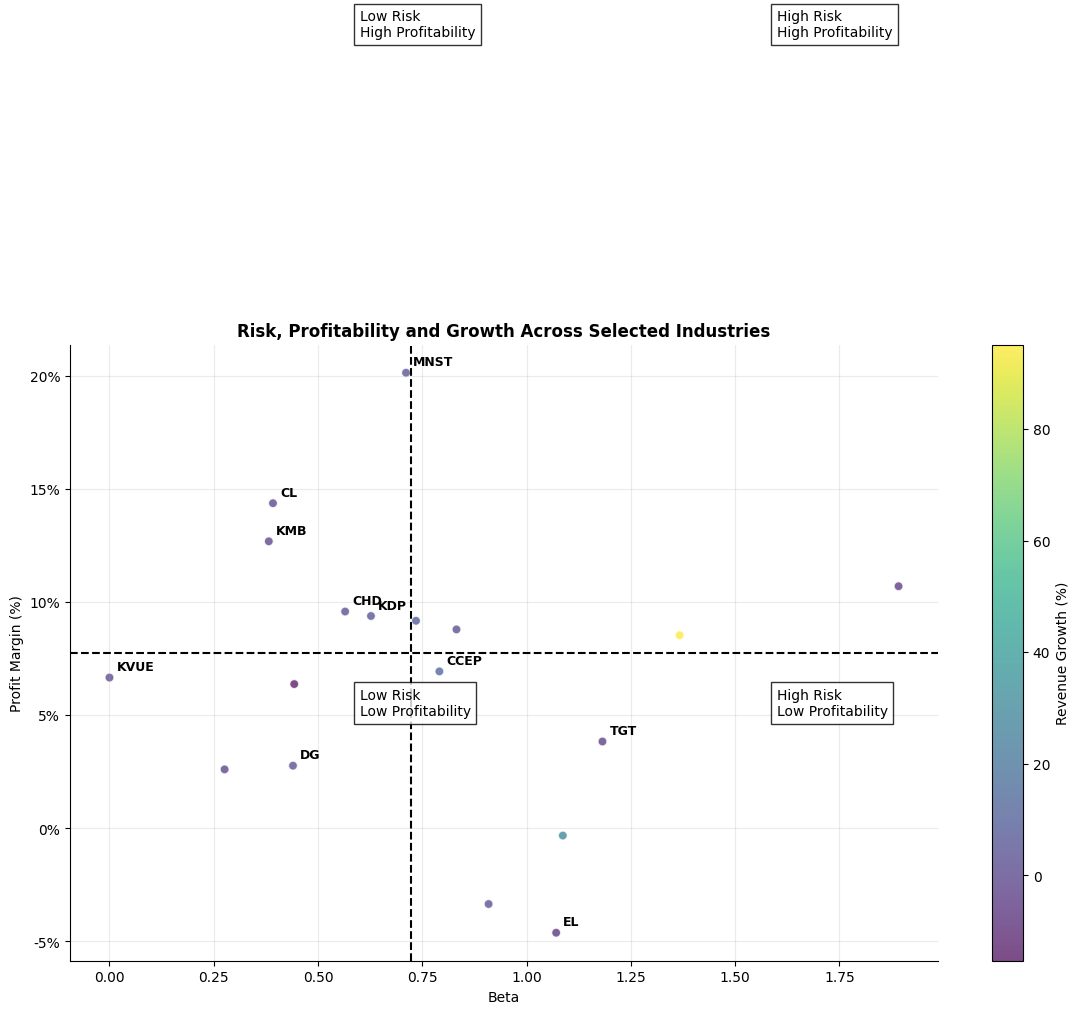

In [ ]:
# X-axis: beta -> measures market risk and volatility.
# Y-axis: profit margins -> measures profitability.
# Bubble size: market capitalization.
# Bubble color: revenue growth.

# Removing missing values.
bubble_df = focus_df.dropna(
    subset=[
        "beta",
        "profit_margins",
        "market_cap_b",
        "revenue_growth"
    ]
).copy()

bubble_df["profit_margin_pct"] = bubble_df["profit_margins"] * 100
bubble_df["revenue_growth_pct"] = bubble_df["revenue_growth"] * 100

# Bubble sizes.
sizes = (bubble_df["market_cap_b"] / 2).clip(lower=40, upper=1500)


# Creating chart
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(
    bubble_df["beta"],
    bubble_df["profit_margin_pct"],
    s=sizes,
    c=bubble_df["revenue_growth_pct"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="white",
    linewidth=0.8
)


# Quadrant lines

beta_median = bubble_df["beta"].median()
margin_median = bubble_df["profit_margin_pct"].median()

ax.axvline(beta_median, color="black", linestyle="--")
ax.axhline(margin_median, color="black", linestyle="--")


# Quadrant labels

ax.text(
    0.6,
    35,
    "Low Risk\nHigh Profitability",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.text(
    1.6,
    35,
    "High Risk\nHigh Profitability",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.text(
    0.6,
    5,
    "Low Risk\nLow Profitability",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.text(
    1.6,
    5,
    "High Risk\nLow Profitability",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

# Annotate largest companies


top_labels = bubble_df.nlargest(10, "market_cap_b")

for _, row in top_labels.iterrows():
    ax.annotate(
        row["symbol"],
        (row["beta"], row["profit_margin_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

# Labels and title


ax.set_title(
    "Risk, Profitability and Growth Across Selected Industries"
)

ax.set_xlabel("Beta")
ax.set_ylabel("Profit Margin (%)")

ax.yaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.grid(alpha=0.25)

clean_spines(ax)

# Colorbar.
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Revenue Growth (%)")

plt.show()

<h1 style="color:green;">
Step 7 — Zoom into One Quadrant
</h1>

In [23]:
import yfinance as yf

# I am focusing on companies with: below-median beta (lower risk), above-median profitability
#This quadrant represents stable and profitable companies,which are typical characteristics of defensive sectors.

selected_quadrant = bubble_df[
    (bubble_df["beta"] <= beta_median) &
    (bubble_df["profit_margin_pct"] >= margin_median)
].copy()

# Only top 10 companies by market capitalization.
selected_quadrant = selected_quadrant.nlargest(
    10,
    "market_cap_b"
)

# Selected companies.
selected_quadrant[
    ["symbol", "company_name", "industry"]
]

,symbol,company_name,industry
161,CL,Colgate-Palmolive Company,Household & Personal Products
213,MNST,Monster Beverage Corporation,Beverages - Non-Alcoholic
253,KMB,Kimberly-Clark Corporation,Household & Personal Products
257,KDP,Keurig Dr Pepper Inc.,Beverages - Non-Alcoholic
396,CHD,"Church & Dwight Company, Inc.",Household & Personal Products


In [24]:
# Download stock prices
# I am building a ticker list.
tickers = selected_quadrant["symbol"].tolist()

# last 3 months of daily prices.
data = yf.download(
    tickers,
    period="3mo",
    interval="1d",
    auto_adjust=True
)

# only closing prices.
closing_prices = data["Close"]

closing_prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,CHD,CL,KDP,KMB,MNST
Date,,,,,
2026-02-17,99.889999,95.059227,28.874960,106.208153,82.900002
2026-02-18,102.669998,94.989662,28.884872,108.559120,83.180000
2026-02-19,103.250000,93.399544,28.845224,107.354004,81.989998
2026-02-20,103.080002,94.502678,29.281372,107.689850,83.760002
2026-02-23,105.260002,96.500267,29.509357,109.161674,84.690002


In [29]:
# Normalize stock prices

# I am normalizing all series to 1 at the first date.
normalized_prices = (
    closing_prices / closing_prices.iloc[0]
)

normalized_prices.head()

Ticker,CHD,CL,KDP,KMB,MNST
Date,,,,,
2026-02-17,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-18,1.027831,0.999268,1.000343,1.022135,1.003378
2026-02-19,1.033637,0.982541,0.998970,1.010789,0.989023
2026-02-20,1.031935,0.994145,1.014075,1.013951,1.010374
2026-02-23,1.053759,1.015159,1.021971,1.027809,1.021592


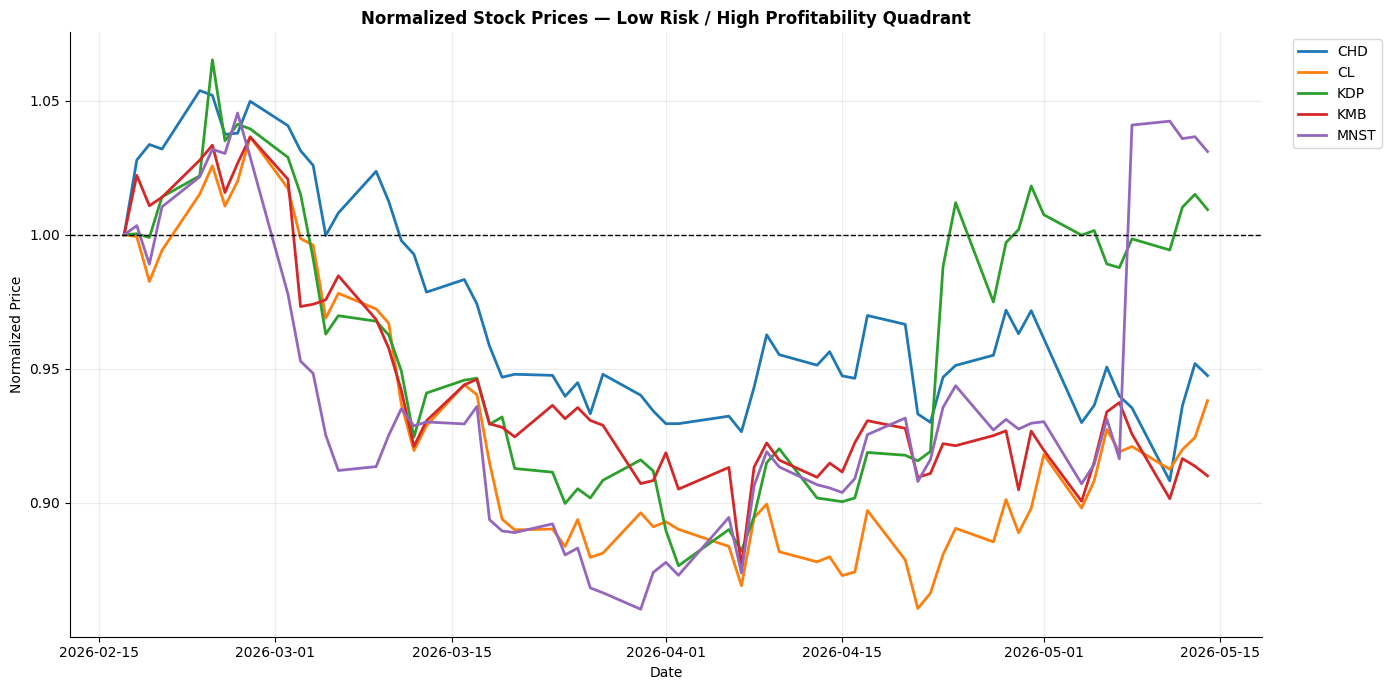

In [30]:
# Plot normalized prices


fig, ax = plt.subplots(figsize=(14, 7))

# Plot all companies.
for ticker in normalized_prices.columns:

    ax.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        linewidth=2,
        label=ticker
    )

# Reference line.
ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1
)

# Labels and title.
ax.set_title(
    "Normalized Stock Prices — Low Risk / High Profitability Quadrant"
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")

ax.grid(alpha=0.25)

clean_spines(ax)

# Legend.
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

#Companies in this quadrant seemed to do well when there were problems between countries. 
# Most companies had slowly rising prices with not a lot of ups and downs especially when compared to other areas
#  that are more affected by what is happening in the world. This makes sense because the Consumer Defensive sector is, 
# about being safe and stable so it is what we would expect from the Consumer Defensive sector.

<h1 style="color:green;">
Step 8 — Compare with an Excluded Quadrant
</h1>

In [32]:
# I now analyze a different quadrant from the bubble chart.
# This group contains companies with higher beta (higher market risk)
# and lower profitability.
#
# Compared with the previous quadrant, these companies may be more exposed
# to volatility during periods of geopolitical uncertainty.
#
# Stock prices moved up and down more and were not as stable during the period we analyzed.
# This makes sense because companies like these usually react more strongly
# to market movements and may not have as much financial stability
# during difficult periods.

comparison_quadrant = bubble_df[(bubble_df["beta"] > beta_median) &(bubble_df["profit_margin_pct"] < margin_median)].copy()


comparison_quadrant[["symbol", "company_name", "industry"]]

,symbol,company_name,industry
246,TGT,Target Corporation,Discount Stores
295,CCEP,Coca-Cola Europacific Partners,Beverages - Non-Alcoholic
423,EL,"Estee Lauder Companies, Inc. (T",Household & Personal Products
609,DLTR,"Dollar Tree, Inc.",Discount Stores
677,PRMB,Primo Brands Corporation,Beverages - Non-Alcoholic


In [25]:
import yfinance as yf

# I will use only reliable tickers for the comparison.
comparison_tickers = ["TGT", "EL"]

# only last 3 months of prices.
comparison_data = yf.download(comparison_tickers,period="3mo",interval="1d",auto_adjust=True)

comparison_prices = comparison_data["Close"]

comparison_prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,EL,TGT
Date,,
2026-02-17,111.789246,115.449234
2026-02-18,111.250931,114.577469
2026-02-19,111.390495,114.577469
2026-02-20,113.872711,115.597832
2026-02-23,112.666489,112.279182


In [26]:
# Normalize all series to 1 at the first trading day.
comparison_normalized = (comparison_prices / comparison_prices.iloc[0])

comparison_normalized.head()

Ticker,EL,TGT
Date,,
2026-02-17,1.000000,1.000000
2026-02-18,0.995185,0.992449
2026-02-19,0.996433,0.992449
2026-02-20,1.018637,1.001287
2026-02-23,1.007847,0.972542


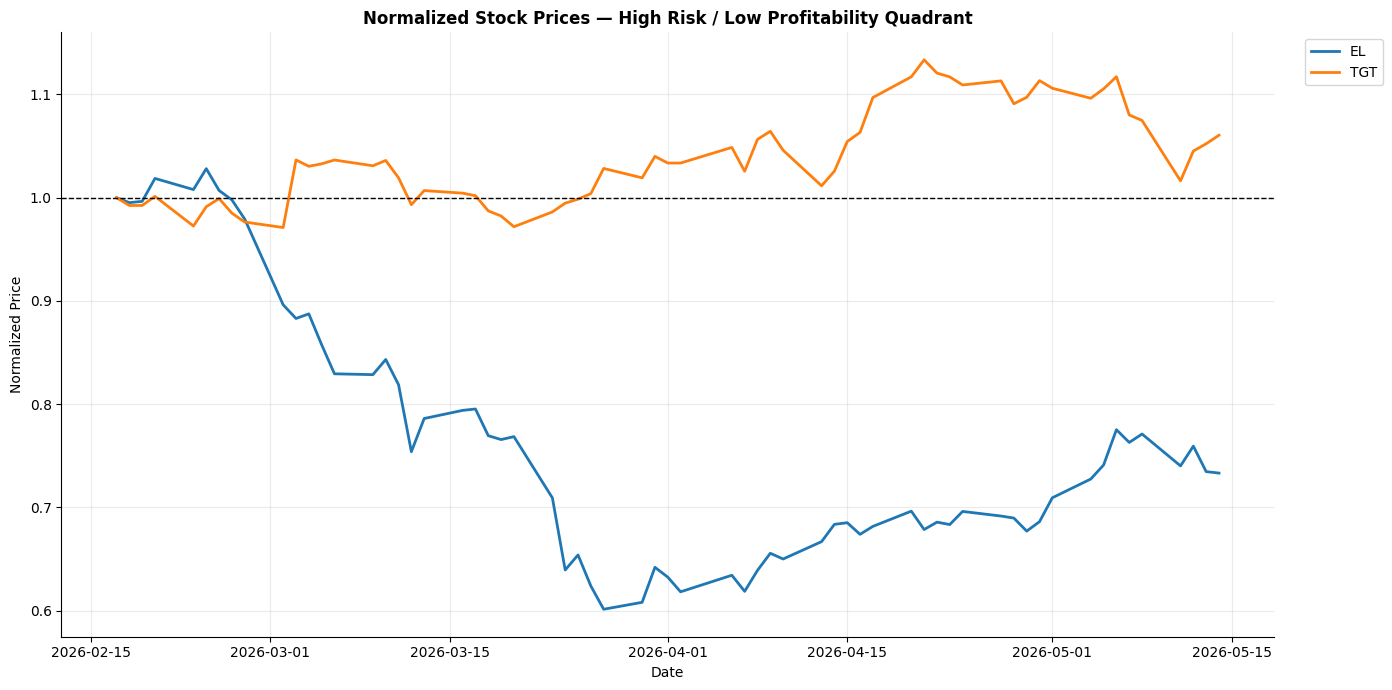

In [27]:
# Plot normalized prices
fig, ax = plt.subplots(figsize=(14, 7))

# Plot all companies.
for ticker in comparison_normalized.columns:

    ax.plot(comparison_normalized.index,comparison_normalized[ticker],linewidth=2,label=ticker)

# Reference line.
ax.axhline(1,color="black", linestyle="--", linewidth=1)

# Title and labels.
ax.set_title("Normalized Stock Prices — High Risk / Low Profitability Quadrant")

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")

# Adding subtle grid.
ax.grid(alpha=0.25)

# Cleaning chart borders.
clean_spines(ax)

# Legend.
ax.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()

plt.show()

<h1 style="color:green;">
Final Summary
</h1>
The Consumer Defensive sector looks pretty stable, profitable, and generally more resilient than sectors that are more affected by the economy. Most of the companies in this sector sell products that people continue to buy even during difficult periods, which helps keep revenues and profits relatively stable.When we first looked at the distribution of companies, we noticed that a few very large companies, such as Walmart and Costco, had a huge impact on the dataset. These companies were affecting the analysis too much, so we removed the extreme values using the IQR method to make the charts easier to read and interpret.

Compared to the previous group, the companies in this quadrant appeared more volatile and less resilient. Their stock prices showed bigger fluctuations and weaker recovery patterns during the observed period.
The industry comparison showed several interesting differences between industries. Discount Stores had the highest market capitalization and revenue levels, mainly because of the presence of very large retailers. Tobacco companies appeared extremely profitable, while Beverage and Household Products companies looked more balanced in terms of profitability and risk.

The boxplots also showed that some industries had much more variability than others. In some cases, companies within the same industry behaved very differently, suggesting that certain industries are more heterogeneous and less stable.
Based on these observations, we selected four industries for deeper analysis: Discount Stores, Beverages - Non-Alcoholic, Household & Personal Products, and Tobacco. We chose these industries because they combined meaningful size, profitability, and different levels of risk, making the comparison more interesting and balanced.

The bubble chart helped us visualize profitability, growth, risk, and company size all in one chart. Larger and more profitable companies generally appeared in the lower-risk area, confirming the defensive nature of the sector. At the same time, some companies showed stronger growth but also higher sensitivity to market movements.

When analyzing stock prices, we noticed that companies with lower risk and higher profitability performed better during the selected period. Their prices remained relatively stable despite geopolitical tensions related to the Strait of Hormuz. On the other hand, higher-risk companies experienced greater volatility and weaker overall performance. This suggests that profitability and risk helped explain why companies reacted differently during periods of market uncertainty